In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score




from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/nursery_data.csv")

In [ ]:
df= df.drop(['finance','children', 'form'],axis=1)
print(df.columns)

# Drop rows with NaN values
df = df.dropna()

# # Drop rows from index 10000 to 12961 (inclusive)
df = df.drop(df.index[2000:12961])

# Separate X (features) and y (target)
X = df.drop('decision', axis=1)
y = df['decision']

Index(['parents', 'has_nurs', 'housing', 'social', 'health', 'decision'], dtype='object')


In [ ]:

X = pd.get_dummies(X)

In [ ]:
X

,parents_usual,has_nurs_improper,has_nurs_less_proper,has_nurs_proper,housing_convenient,housing_critical,housing_less_conv,social_nonprob,social_problematic,social_slightly_prob,health_not_recom,health_priority,health_recommended
0,True,False,False,True,True,False,False,True,False,False,False,False,True
1,True,False,False,True,True,False,False,True,False,False,False,True,False
2,True,False,False,True,True,False,False,True,False,False,True,False,False
3,True,False,False,True,True,False,False,False,False,True,False,False,True
4,True,False,False,True,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,True,True,False,False,False,True,False,False,True,False,False,False,True
1996,True,True,False,False,False,True,False,False,True,False,False,True,False
1997,True,True,False,False,False,True,False,False,True,False,True,False,False
1998,True,True,False,False,True,False,False,True,False,False,False,False,True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, train_size=0.67, random_state=42)


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklea

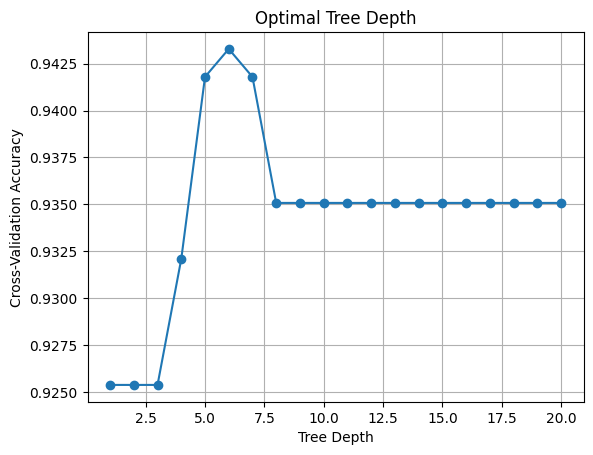

Optimal Depth: 6


In [ ]:
# Determine optimal tree depth using cross-validation
max_depths = range(1, 21)
cv_scores = []

for depth in max_depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth)
    scores = cross_val_score(model, X_train, y_train, cv=5)  # 5-fold cross-validation
    cv_scores.append(np.mean(scores))

# Plot the cross-validation scores
plt.plot(max_depths, cv_scores, marker='o')
plt.xlabel('Tree Depth')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Optimal Tree Depth')
plt.grid()
plt.show()

# Find the depth with the highest cross-validation score
optimal_depth = max_depths[np.argmax(cv_scores)]
print(f"Optimal Depth: {optimal_depth}")

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklea

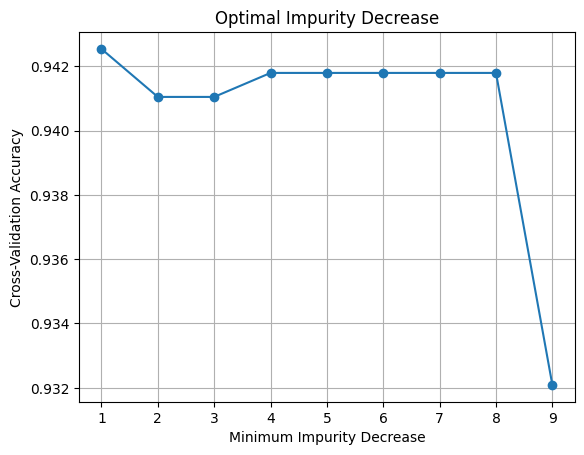

Optimal Impurity Decrease: 1


In [ ]:
min_impurity_decrease = range(1, 10)

cv_scores_imp = []

for impurity in min_impurity_decrease:
    model = DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=impurity/1000, max_depth=optimal_depth)
    scores_imp = cross_val_score(model, X_train, y_train, cv=5)  # 5-fold cross-validation
    cv_scores_imp.append(np.mean(scores_imp))

# Plot the cross-validation scores
plt.plot(min_impurity_decrease, cv_scores_imp, marker='o')
plt.xlabel('Minimum Impurity Decrease')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Optimal Impurity Decrease')
plt.grid()
plt.show()

# Find the depth with the highest cross-validation score
optimal_impurity_decrease = min_impurity_decrease[np.argmax(cv_scores_imp)]
print(f"Optimal Impurity Decrease: {optimal_impurity_decrease}")

In [ ]:
# Check the distribution of classes in the training and test sets
print("Class distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())

Class distribution in y_train:
decision
priority      791
not_recom     449
very_recom     98
recommend       2
Name: count, dtype: int64

Class distribution in y_test:
decision
priority      378
not_recom     217
very_recom     65
Name: count, dtype: int64


In [ ]:
clf = DecisionTreeClassifier(criterion='gini') # Adjust max_depth as needed
clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
confusion_mat = confusion_matrix(y_test,y_pred)

In [ ]:
print("Unique values in y_test:", set(y_test))
print("Unique values in y_pred:", set(y_pred))

# Create a DataFrame for the confusion matrix
unique_classes = sorted(set(y_test) | set(y_pred))
confusion_df = pd.DataFrame(confusion_mat, index=unique_classes, columns=unique_classes)

print(confusion_df)

Unique values in y_test: {'not_recom', 'priority', 'very_recom'}
Unique values in y_pred: {'not_recom', 'priority', 'very_recom'}
            not_recom  priority  very_recom
not_recom         217         0           0
priority            0       366          12
very_recom          0        24          41


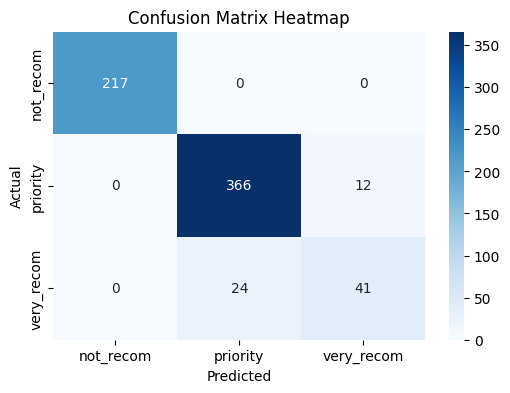

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_df, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)
plt.show()

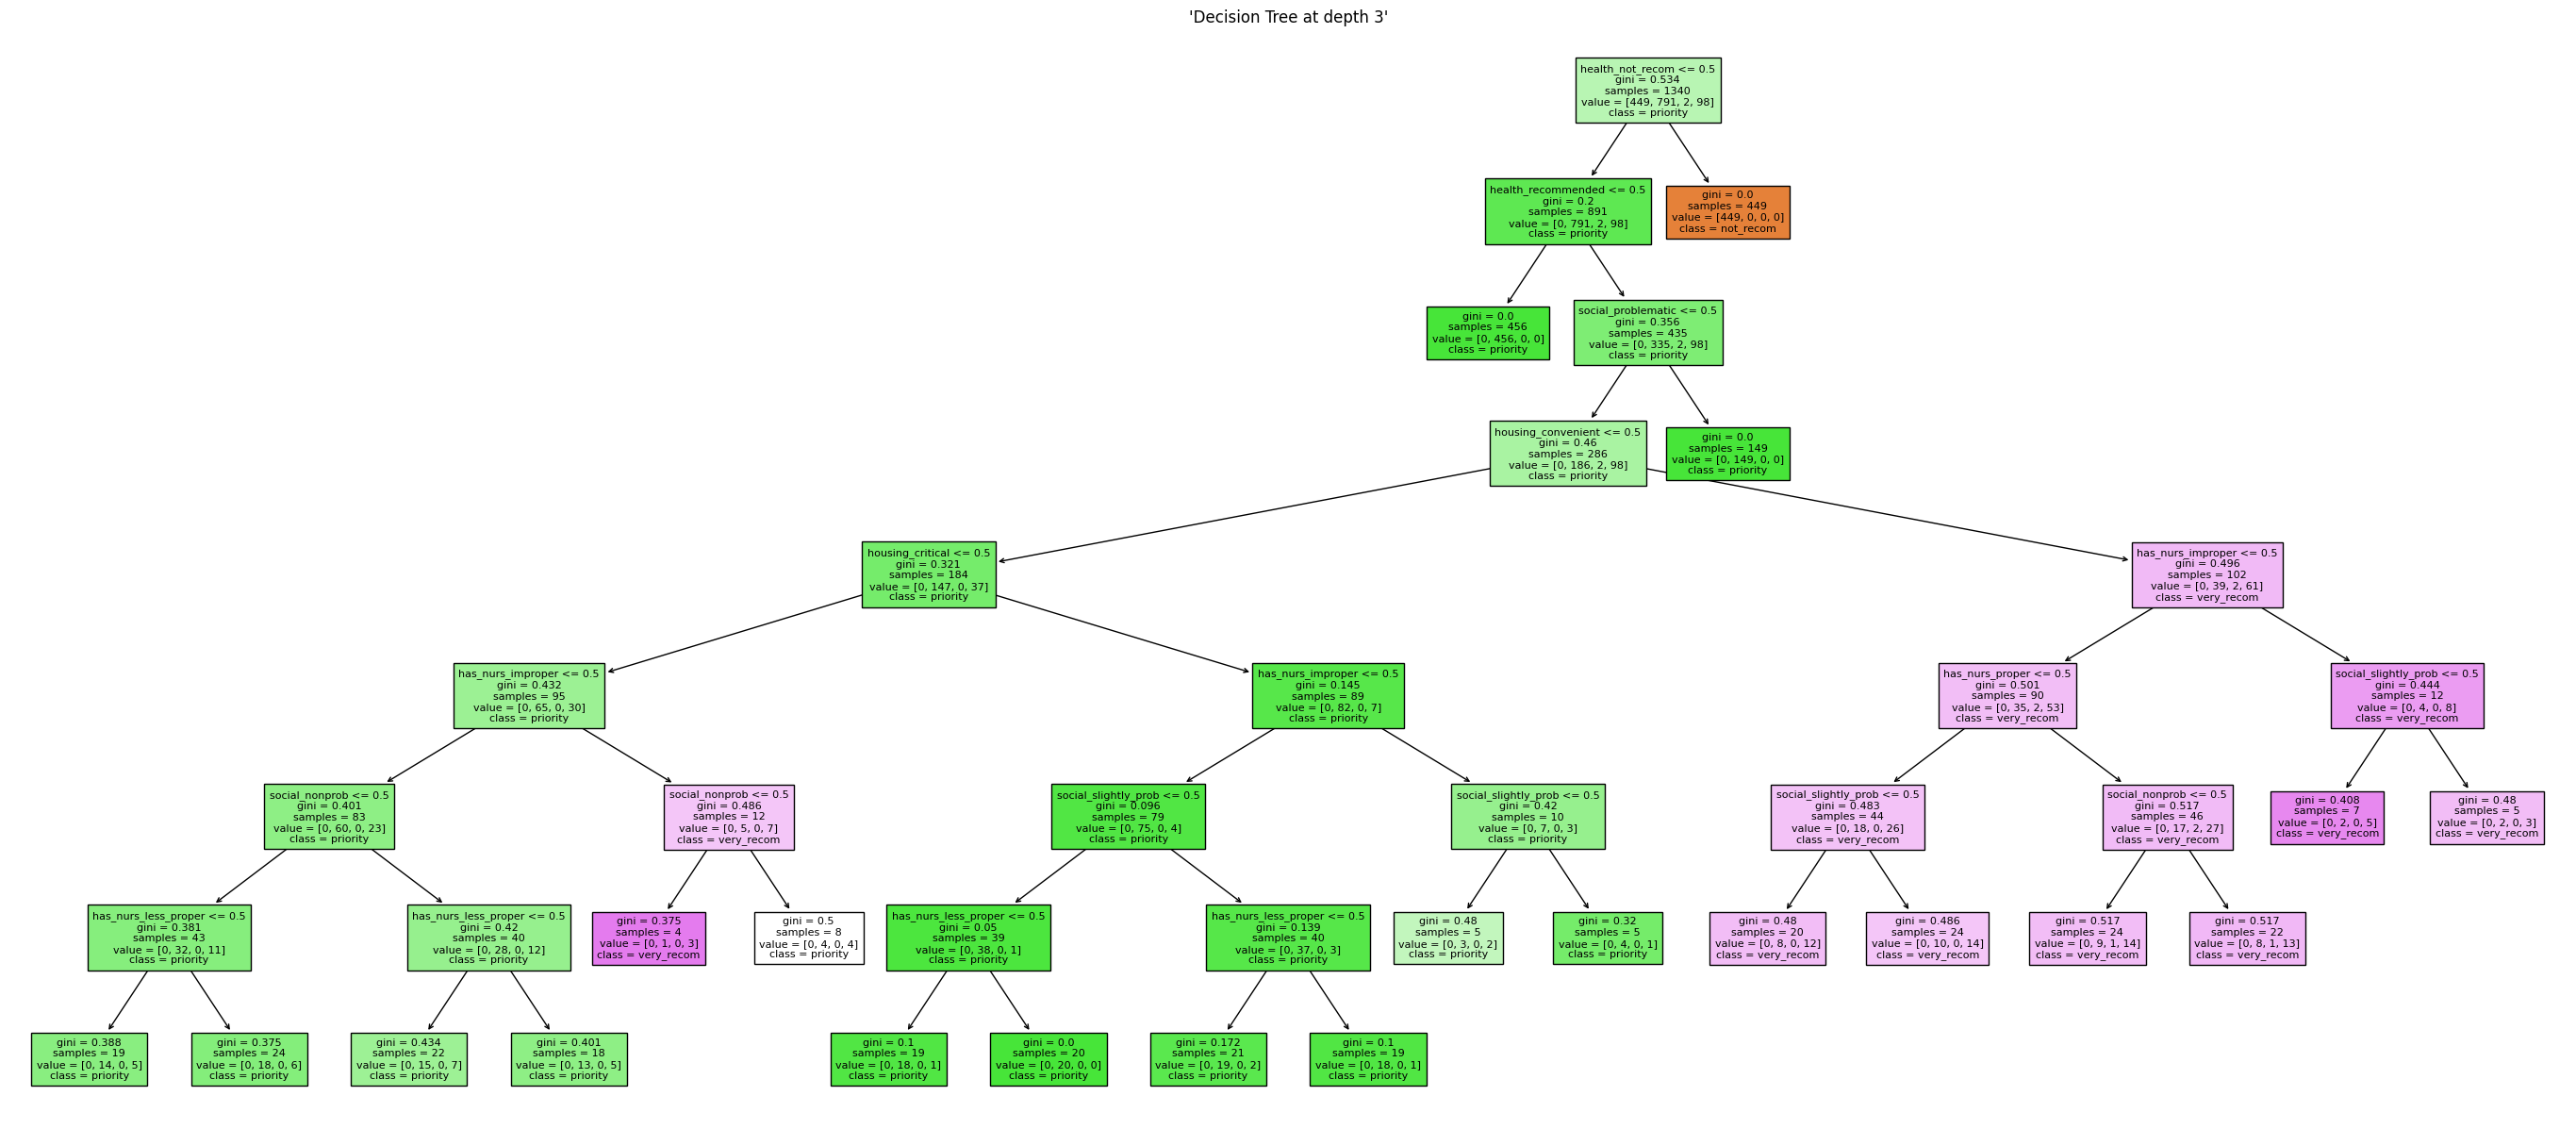

In [ ]:
# plt.figure(figsize=(20, 10))
# tree.plot_tree(clf, filled=True, feature_names=X.columns, class_names=np.unique(y).astype('str'), fontsize=5)
# plt.title("Decision Tree")
# plt.savefig('depth17.png', dpi=200)
# plt.show()

plt.figure(figsize=(35, 15))
# Check if X is a DataFrame and extract column names if it is
feature_names = X.columns if isinstance(X, pd.DataFrame) else None
tree.plot_tree(clf, filled=True, feature_names=feature_names,
               class_names=np.unique(y).astype('str'), fontsize=8)
plt.title("'Decision Tree at depth 3'")
plt.savefig('depth17.png', dpi=200)
plt.show()



# plt.figure(figsize=(20, 10))
# # Check if X is a DataFrame and extract column names if it is
# feature_names = X.columns if isinstance(X, pd.DataFrame) else None
# tree.plot_tree(clf, filled=True, feature_names=feature_names,
#                class_names=np.unique(y).astype('str'), fontsize=5,
#                # Parameters for node spacing and branch length
#                node_ids=False,  # Hide node IDs for cleaner look
#                proportion=True, # Display proportions instead of counts
#                rounded=True)   # Rounded corners for nodes
# plt.title("Decision Tree")
# plt.savefig('depth17.png', dpi=200)
# plt.show()

In [ ]:
# Calculate F1 score
f1 = f1_score(y_test, y_pred, average='weighted') # Use 'weighted' for multiclass

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision
precision = precision_score(y_test, y_pred, average='weighted') # Use 'weighted' for multiclass

# Calculate recall
recall = recall_score(y_test, y_pred, average='weighted') # Use 'weighted' for multiclass

print("F1 Score:", f1)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:",recall)


F1 Score: 0.9417056780428874
Accuracy: 0.9454545454545454
Precision: 0.9420916124494461
Recall: 0.9454545454545454


In [ ]:
from sklearn.metrics import classification_report

# Assuming y_test and y_pred are already defined
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       217
    priority       0.94      0.97      0.95       378
  very_recom       0.77      0.63      0.69        65

    accuracy                           0.95       660
   macro avg       0.90      0.87      0.88       660
weighted avg       0.94      0.95      0.94       660



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


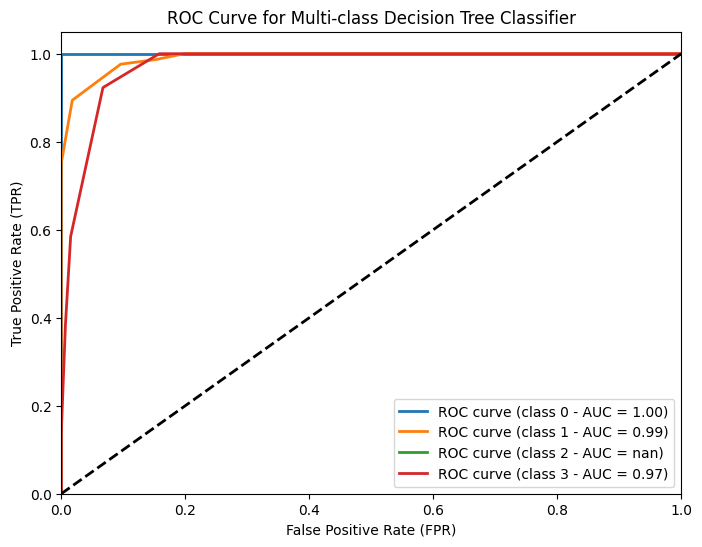

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report
from google.colab import drive
# ROC curve for multi-class
# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Learn to predict each class against the other
classifier = OneVsRestClassifier(DecisionTreeClassifier(criterion='gini', max_depth=4))
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve (class {i} - AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Multi-class Decision Tree Classifier')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png', dpi=200)
plt.show()